### Getting and preparing data

In [34]:
# All imports go here
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
import statistics
import xgboost as xgb

In [2]:
# Getting dataset
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
!wget $data -O car_fuel_efficiency.csv

--2025-11-09 23:54:17--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K   405KB/s    in 2.1s    

2025-11-09 23:54:20 (405 KB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [3]:
df = pd.read_csv('car_fuel_efficiency.csv')

# Checking missing values
missing_counts = df.isnull().sum()
print(missing_counts)

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64


In [4]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [5]:
# Filling missing values
df = df.fillna(0)

In [6]:
# Data split 60/20/20 with random state equal to 1
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [7]:
# Preperaing for DictVectorizer
df_train = df_train.reset_index(drop=True)
y_train = df_train.fuel_efficiency_mpg.values
y_train

array([15.3014754 , 15.33121466, 15.33667895, ..., 15.18828665,
       17.3967514 , 16.16090373], shape=(5822,))

In [8]:
del df_train['fuel_efficiency_mpg']
df_train.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
dtype: object

In [9]:
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# Remove the column to predict to avoid accidental usage
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

### Question 1. Most important featute

In [10]:
dict_train = df_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dict_train)

dict_test = df_test.to_dict(orient='records')
X_test = dv.transform(dict_test)

In [11]:
# Training the model
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [12]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



### Question 2. RMSE on validation

In [13]:
# Training the model
rf = RandomForestRegressor(
    n_estimators=10, 
    random_state=1,
    n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# RMSE function
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [15]:
dict_val = df_val.to_dict(orient='records')
X_val = dv.transform(dict_val)

y_pred = rf.predict(X_val)

In [18]:
error = rmse(y_val, y_pred)
print('Anwswer 2 is', error)

Anwswer 2 is 0.4599777557336148


### Question 3. Number of estimators

In [23]:
# Training models for various values of estimators
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    mse = rmse(y_val, y_pred)
    scores.append((n, round(mse, 4)))

In [25]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
df_scores

,n_estimators,rmse
0,10,0.4600
1,20,0.4537
2,30,0.4507
3,40,0.4480
4,50,0.4462
5,60,0.4453
6,70,0.4446
7,80,0.4449
8,90,0.4447
9,100,0.4443


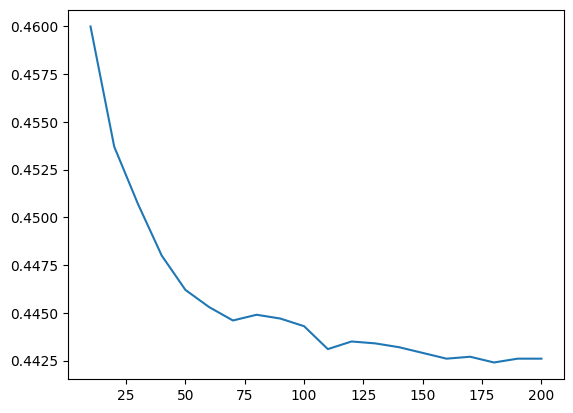

In [29]:
plt.plot(df_scores.n_estimators, df_scores.rmse)

### Question 4. Best max_depth

In [32]:
# Training for different max depth
scores = []

for d in [10, 15, 20, 25]:
    mse_values = []
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_val)
        mse = rmse(y_val, y_pred)
        mse_values.append(mse)
    mean = statistics.fmean(mse_values)
    scores.append((d, mean))

df_scores = pd.DataFrame(scores, columns=['max_depth', 'mean_rmse'])
df_scores

,max_depth,mean_rmse
0,10,0.442321
1,15,0.445060
2,20,0.445644
3,25,0.445661


### Question 5. Most important feature

In [35]:
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Get feature names from DictVectorizer
feature_names = dv.get_feature_names_out()

# Create a dictionary to see importances with their feature names
importance_dict = dict(zip(feature_names, feature_importances))

# Find the most important among the 4 specified features
features_to_check = ['vehicle_weight', 'horsepower', 'acceleration', 'engine_displacement']

for feature in features_to_check:
    if feature in importance_dict:
        print(f"{feature}: {importance_dict[feature]:.4f}")

# Or find the maximum
max_importance = max([(f, importance_dict[f]) for f in features_to_check if f in importance_dict], 
                     key=lambda x: x[1])
print(f"\nAnswer 5: {max_importance[0]} with importance {max_importance[1]:.4f}")

vehicle_weight: 0.9592
horsepower: 0.0160
acceleration: 0.0115
engine_displacement: 0.0033

Answer 5: vehicle_weight with importance 0.9592


### Question 6. XGBoost eta

In [36]:
# Create DMatrix for train and validation
features=dv.get_feature_names_out()
features=features.tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [37]:
# Create a watchlist
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [39]:
# Train a model with these parameters for 100 rounds
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

[0]	train-rmse:1.81393	val-rmse:1.85444
[5]	train-rmse:0.51381	val-rmse:0.55664
[10]	train-rmse:0.37115	val-rmse:0.43896
[15]	train-rmse:0.34666	val-rmse:0.43362
[20]	train-rmse:0.33553	val-rmse:0.43376
[25]	train-rmse:0.32268	val-rmse:0.43683
[30]	train-rmse:0.31475	val-rmse:0.43752
[35]	train-rmse:0.30960	val-rmse:0.43784
[40]	train-rmse:0.30202	val-rmse:0.43968
[45]	train-rmse:0.29126	val-rmse:0.44024
[50]	train-rmse:0.28456	val-rmse:0.44140
[55]	train-rmse:0.27618	val-rmse:0.44225
[60]	train-rmse:0.26768	val-rmse:0.44290
[65]	train-rmse:0.26174	val-rmse:0.44352
[70]	train-rmse:0.25489	val-rmse:0.44531
[75]	train-rmse:0.24792	val-rmse:0.44628
[80]	train-rmse:0.24254	val-rmse:0.44689
[85]	train-rmse:0.23644	val-rmse:0.44749
[90]	train-rmse:0.23193	val-rmse:0.44839
[95]	train-rmse:0.22475	val-rmse:0.44904
[99]	train-rmse:0.21950	val-rmse:0.45018


In [40]:
# Score for 0.3
y_pred = model.predict(dval)
rmse(y_val, y_pred)

np.float64(0.45017755678087246)

In [41]:
# Train a model with these parameters for 100 rounds
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

[0]	train-rmse:2.28944	val-rmse:2.34561
[5]	train-rmse:1.41247	val-rmse:1.44988
[10]	train-rmse:0.91008	val-rmse:0.94062
[15]	train-rmse:0.63402	val-rmse:0.66672
[20]	train-rmse:0.48983	val-rmse:0.53064
[25]	train-rmse:0.41881	val-rmse:0.46891
[30]	train-rmse:0.38342	val-rmse:0.44289
[35]	train-rmse:0.36435	val-rmse:0.43250
[40]	train-rmse:0.35343	val-rmse:0.42746
[45]	train-rmse:0.34621	val-rmse:0.42595
[50]	train-rmse:0.33998	val-rmse:0.42498
[55]	train-rmse:0.33480	val-rmse:0.42449
[60]	train-rmse:0.33054	val-rmse:0.42456
[65]	train-rmse:0.32602	val-rmse:0.42493
[70]	train-rmse:0.32202	val-rmse:0.42503
[75]	train-rmse:0.31895	val-rmse:0.42526
[80]	train-rmse:0.31667	val-rmse:0.42563
[85]	train-rmse:0.31440	val-rmse:0.42574
[90]	train-rmse:0.31059	val-rmse:0.42586
[95]	train-rmse:0.30625	val-rmse:0.42611
[99]	train-rmse:0.30419	val-rmse:0.42623


In [42]:
# Score for 0.1
y_pred = model.predict(dval)
rmse(y_val, y_pred)

np.float64(0.42622800553359225)